In [1]:
# импортируем необходимые библиотекм
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
# импортируем модуль os
import os

# выводим пути к папкам (dirpath) и наименования файлов (filenames) и после этого
for dirpath, _, filenames in os.walk('/content/'):

  # во вложенном цикле проходимся по названиям файлов
  for filename in filenames:

    # и соединяем путь до папок и входящие в эти папки файлы
    # с помощью метода path.join()
    print(os.path.join(dirpath, filename))

Загрузка таблиц

In [2]:
# посмотрим на первые 5 записей файла Books.csv
books = pd.read_csv('Books.csv')
books.head(5)

C:\Users\User\AppData\Local\Temp\ipykernel_22352\335995001.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('Books.csv')


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [3]:
# посмотрим на первые 5 записей файла Raitings.csv
Ratings = pd.read_csv('Ratings.csv')
Ratings.head(5)

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [4]:
# посмотрим на первые 5 записей файла Users.csv
users = pd.read_csv('Users.csv')
users.head(5)

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


Разведовочный анализ данных. 

Проверяем типы данных и пропусков.

In [5]:
# Получим информацию о наборе данных
Ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [6]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [7]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [8]:
# выявим пропущенные значения с помощью .isnull()
# и посчитаем их количество через sum()
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [9]:
books_cleaned = books.dropna(subset=['Book-Author', 'Publisher'])
books_cleaned.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [10]:
Ratings.shape

(1149780, 3)

In [11]:
df_ratings = Ratings['User-ID'].value_counts()
df_ratings.sort_values(ascending=False).head()

User-ID
11676     13602
198711     7550
153662     6109
98391      5891
35859      5850
Name: count, dtype: int64

Многие книги могут быть представлены в разных изданиях (с разными издателями или годами). Для рекомендаций нам нужны уникальные книги.

In [12]:
# Удалить строки с повторяющимся названием книги
new_books = books.drop_duplicates('Book-Title')
# Объединить ratings и new_books df
ratings_with_name = Ratings.merge(new_books, on='ISBN')

# Удалить ненужные столбцы
ratings_with_name.drop(['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis = 1, inplace = True)
# Объединить новый 'ratings_with_name' df с users df
users_ratings_matrix = ratings_with_name.merge(users, on='User-ID')

# Удалить ненужные столбцы
users_ratings_matrix.drop(['Location', 'Age'], axis = 1, inplace = True)

# Напечатать первые несколько строк нового фрейма данных
users_ratings_matrix.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books
1,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press
2,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press
3,276746,0425115801,0,Lightning,Dean R. Koontz,1996,Berkley Publishing Group
4,276746,0449006522,0,Manhattan Hunt Club,JOHN SAUL,2002,Ballantine Books


In [13]:
# Проверька наличия нулевых значений
users_ratings_matrix.isna().sum()
# Отбросить нулевые значения
users_ratings_matrix.dropna(inplace = True)
print(users_ratings_matrix.isna().sum())

User-ID                0
ISBN                   0
Book-Rating            0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
dtype: int64


Фильтрация данных для повышения релевантности: Исходная матрица слишком велика и разрежена (много нулей). Чтобы улучшить качество рекомендаций, мы фильтруем

In [14]:
# Отфильтруем 'users_ratings_matrix' на основе пользователей, которые дали много оценок книгам
x = users_ratings_matrix.groupby('User-ID').count()['Book-Rating'] > 100
knowledgeable_users = x[x].index
filtered_users_ratings = users_ratings_matrix[users_ratings_matrix['User-ID'].isin(knowledgeable_users)]

# Отфильтруем "users_ratings_матрицу" на основе книг с наибольшим количеством оценок
y = filtered_users_ratings.groupby('Book-Title').count()['Book-Rating'] >= 50
famous_books = y[y].index
final_users_ratings = filtered_users_ratings[filtered_users_ratings['Book-Title'].isin(famous_books)]

# Создание сводной таблицы
pivot_table = final_users_ratings.pivot_table(index = 'Book-Title', columns = 'User-ID', values = 'Book-Rating')

# Заполнение значений NA значением "0"
pivot_table.fillna(0, inplace = True)
pivot_table.head()

User-ID,254,507,882,1424,1435,1733,1903,2033,2110,2276,...,274808,275020,275970,276680,277427,277478,277639,278137,278188,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010: Odyssey Two,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# Стандартизирование сводной таблицы
scaler = StandardScaler(with_mean=True, with_std=True)
pivot_table_normalized = scaler.fit_transform(pivot_table)

Пояснение: Стандартизация помогает учесть "строгость" разных пользователей: один может ставить в среднем 8 баллов, а другой — 5. После стандартизации их предпочтения становятся сравнимыми.

Построение модели

Вычисляем попарную схожесть между всеми книгами на основе стандартизированных оценок пользователей.

In [16]:
# Вычислить матрицу сходства для всех книг
similarity_score = cosine_similarity(pivot_table_normalized)

def recommend(book_name):

    # Возвращаем числовой индекс для имени книги
    index = np.where(pivot_table.index==book_name)[0][0]

    # Сортируем сходства для имени книги в порядке убывания
    similar_books = sorted(list(enumerate(similarity_score[index])),key=lambda x:x[1], reverse=True)[1:6]

    # Возвращаем результат в формате списка
    data = []

    for index,similarity in similar_books:
        item = []
        # Получим подробную информацию о книге по указателю
        temp_df = new_books[new_books['Book-Title'] == pivot_table.index[index]]

        # К результату добавим только название, автора и URL-адрес изображения
        item.extend(temp_df['Book-Title'].values)
        item.extend(temp_df['Book-Author'].values)
        item.extend(temp_df['Image-URL-M'].values)

        data.append(item)
    return data

Проверка модели

Протестируем функцию, запросив книги, похожие на "1984" Джорджа Оруэлла.

In [17]:
# Вызовем метод recommend ('1984',similarity_score)
recommend('1984')

[["Foucault's Pendulum",
  'Umberto Eco',
  'http://images.amazon.com/images/P/0345368754.01.MZZZZZZZ.jpg'],
 ['Tis : A Memoir',
  'Frank McCourt',
  'http://images.amazon.com/images/P/0684848783.01.MZZZZZZZ.jpg'],
 ['Animal Farm',
  'George Orwell',
  'http://images.amazon.com/images/P/0451526341.01.MZZZZZZZ.jpg'],
 ['The Glass Lake',
  'Maeve Binchy',
  'http://images.amazon.com/images/P/0440221595.01.MZZZZZZZ.jpg'],
 ['Summer Pleasures',
  'Nora Roberts',
  'http://images.amazon.com/images/P/0373218397.01.MZZZZZZZ.jpg']]

Анализ набора данных о книгах

Изучим уникальность и распределение книг, авторов и издательств.

In [18]:
# Уникальные значения
print("Unique Titles:", books['Book-Title'].nunique())
print("Unique Authors:", books['Book-Author'].nunique())
print("Unique Publishers:", books['Publisher'].nunique())

Unique Titles: 242135
Unique Authors: 102022
Unique Publishers: 16807


Вывод: Количество уникальных названий (242,135) меньше общего количества записей (271,360), что подтверждает наличие дубликатов книг (например, разные издания).

In [19]:
# Лучшие авторы
print("Top 10 Authors:\n", books['Book-Author'].value_counts().head(10))

Top 10 Authors:
 Book-Author
Agatha Christie        632
William Shakespeare    567
Stephen King           524
Ann M. Martin          423
Carolyn Keene          373
Francine Pascal        372
Isaac Asimov           330
Nora Roberts           315
Barbara Cartland       307
Charles Dickens        302
Name: count, dtype: int64


Вывод: Небольшое количество авторов отвечает за непропорционально большое количество книг в dataset.

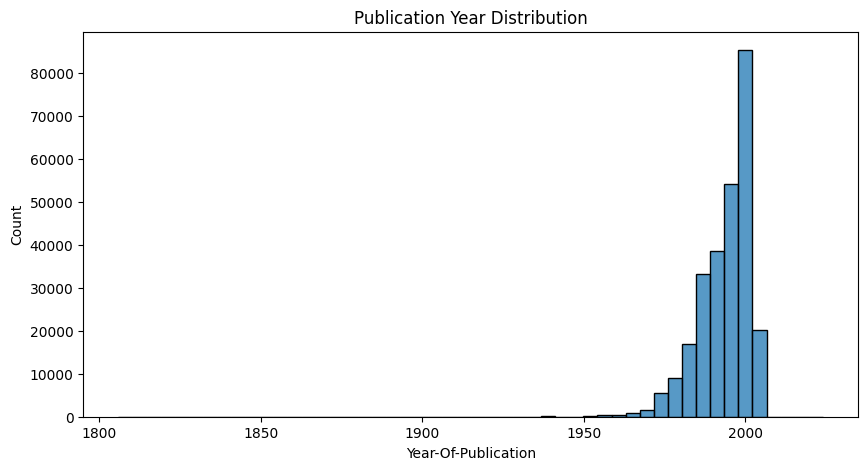

In [20]:
# Текущий год
current_year = datetime.datetime.now().year

# Преобразуем в число
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')

# Заменим нереальные годы на NaN
books.loc[(books['Year-Of-Publication'] < 1500) | (books['Year-Of-Publication'] > current_year), 'Year-Of-Publication'] = pd.NA

# Отбросим значения NaN
books.dropna(subset=['Year-Of-Publication'], inplace=True)

# Преобразуем в int
books['Year-Of-Publication'] = books['Year-Of-Publication'].astype(int)

plt.figure(figsize=(10,5))
sns.histplot(books['Year-Of-Publication'], bins=50, kde=False)
plt.title("Publication Year Distribution")
plt.show()

Вывод: Построена гистограмма распределения книг по годам публикации, которая показала ожидаемый рост числа публикаций с течением времени.

Анализ набора данных о пользователях

Построим демографический портрет пользователей.

In [21]:
# Уникальные пользователи
print("Unique Users:", users['User-ID'].nunique())

Unique Users: 278858


Вывод: Количество уникальных пользователей совпадает с количеством записей, что означает отсутствие явных дубликатов.

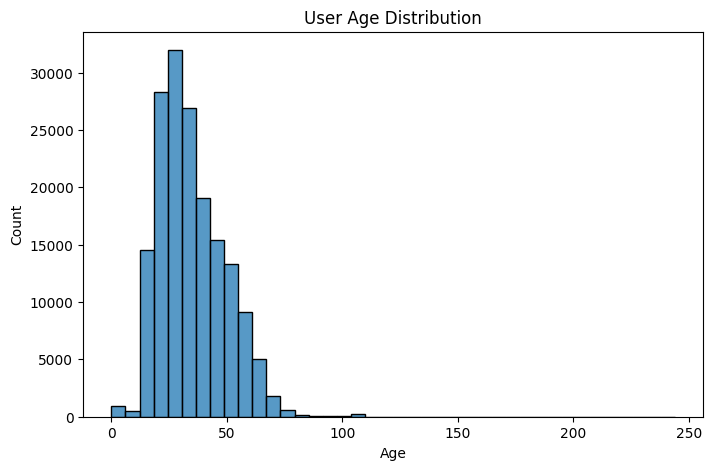

In [22]:
# Распределение по возрасту
plt.figure(figsize=(8,5))
sns.histplot(users['Age'], bins=40, kde=False)
plt.title("User Age Distribution")
plt.show()

Вывод: На гистограмме распределения возраста были обнаружены нереалистичные значения (например, младше 5 и старше 100 лет).

In [23]:
# Отфильтруем нереалистичные возрасты (оставим только 5-100)
users = users[(users['Age'] >= 5) & (users['Age'] <= 100)]

# Топ-локации
print("Top 10 Locations:\n", users['Location'].value_counts().head(10))

Top 10 Locations:
 Location
london, england, united kingdom       1607
sydney, new south wales, australia    1397
madrid, madrid, spain                 1320
toronto, ontario, canada              1223
melbourne, victoria, australia        1052
chicago, illinois, usa                 889
barcelona, barcelona, spain            873
berlin, berlin, germany                783
barcelona, catalunya, spain            767
seattle, washington, usa               740
Name: count, dtype: int64


Вывод: Платформа пользуется популярностью в крупных англоязычных и европейских городах.

Анализ набора данных с рейтингами

In [24]:
# Статистика рейтинга
print("Total Ratings:", Ratings.shape[0])
print("Unique Users in Ratings:", Ratings['User-ID'].nunique())
print("Unique Books in Ratings:", Ratings['ISBN'].nunique())

Total Ratings: 1149780
Unique Users in Ratings: 105283
Unique Books in Ratings: 340556


Вывод: Из 278,858 зарегистрированных пользователей только 105,283 поставили хотя бы одну оценку. Это важный момент для понимания активности аудитории.

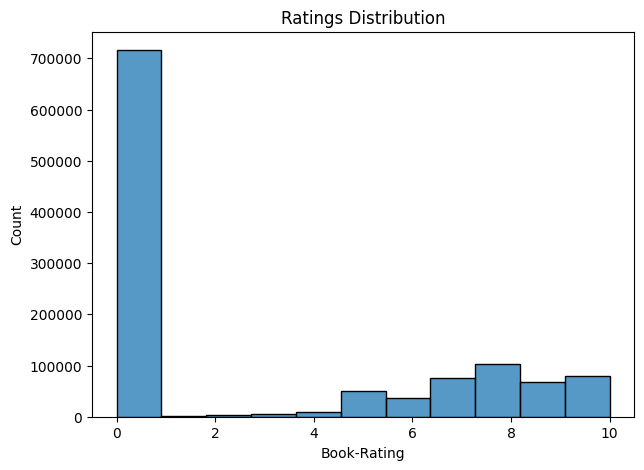

In [25]:
# Распределение рейтингов
plt.figure(figsize=(7,5))
sns.histplot(Ratings['Book-Rating'], bins=11, kde=False)
plt.title("Ratings Distribution")
plt.show()

Гистограмма показывает, что рейтинг 0 является самым распространенным. Это может означать, что "0" используется для обозначения отсутствия рейтинга или негативного отклика, что необходимо учитывать при моделировании.

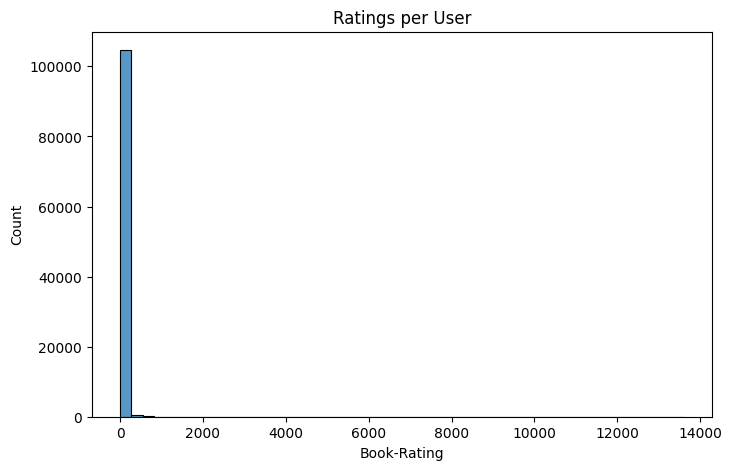

In [26]:
# Рейтинги для каждого пользователя
ratings_per_user = Ratings.groupby('User-ID')['Book-Rating'].count()
plt.figure(figsize=(8,5))
sns.histplot(ratings_per_user, bins=50, kde=False)
plt.title("Ratings per User")
plt.show()

Вывод: Большинство пользователей поставило очень мало оценок.

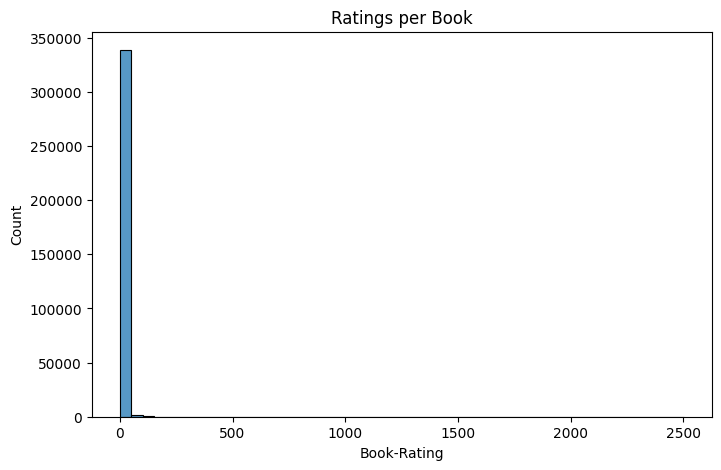

In [27]:
# Рейтинги за книгу
ratings_per_book = Ratings.groupby('ISBN')['Book-Rating'].count()
plt.figure(figsize=(8,5))
sns.histplot(ratings_per_book, bins=50, kde=False)
plt.title("Ratings per Book")
plt.show()

Вывод: Большинство книг получило очень мало оценок.

Построение рекомендательных систем

Принцип: Рекомендовать книги, которые являются наиболее популярными и высокооцененными в целом, без персонализации.

In [28]:
ratings_with_bookname=Ratings.merge(books,on='ISBN')

# Количество оценок по каждой книге
num_rating_df=ratings_with_bookname.groupby('Book-Title').count()['Book-Rating'].reset_index()
num_rating_df.rename(columns={'Book-Rating':'num_ratings'},inplace=True)
num_rating_df

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
237444,Ã?Â?lpiraten.,2
237445,Ã?Â?rger mit Produkt X. Roman.,4
237446,Ã?Â?sterlich leben.,1
237447,Ã?Â?stlich der Berge.,3


In [29]:
average_rating_df=ratings_with_bookname.groupby('Book-Title')['Book-Rating'].mean().reset_index()
average_rating_df.rename(columns={'Book-Rating':'avg_rating'},inplace=True)
average_rating_df

,Book-Title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
237444,Ã?Â?lpiraten.,0.000000
237445,Ã?Â?rger mit Produkt X. Roman.,5.250000
237446,Ã?Â?sterlich leben.,7.000000
237447,Ã?Â?stlich der Berge.,2.666667


In [30]:
# Объединяем average_rating_df и num_rating_df
popularity_df=num_rating_df.merge(average_rating_df,on='Book-Title')
popularity_df

,Book-Title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
237444,Ã?Â?lpiraten.,2,0.000000
237445,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
237446,Ã?Â?sterlich leben.,1,7.000000
237447,Ã?Â?stlich der Berge.,3,2.666667


Топ-50 книг:

In [31]:
popularity_df=popularity_df[popularity_df['num_ratings']>=250].sort_values('avg_rating',ascending=False).head(50)
popularity_df

,Book-Title,num_ratings,avg_rating
79027,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804
79015,Harry Potter and the Goblet of Fire (Book 4),387,5.824289
79034,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410
79019,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441
79007,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453
188465,The Hobbit : The Enchanting Prelude to The Lor...,281,5.007117
184242,The Fellowship of the Ring (The Lord of the Ri...,368,4.948370
79038,Harry Potter and the Sorcerer's Stone (Harry P...,575,4.895652
208194,"The Two Towers (The Lord of the Rings, Part 2)",260,4.880769
216479,To Kill a Mockingbird,510,4.700000


Система рекоммендаций на основе коллаборативной фильтрации

Принцип: Рекомендовать книги на основе сходства вкусов между пользователями. Мы используем item-item подход: "пользователи, которым понравилась эта книга, также с высокой вероятностью понравятся и эти.

In [32]:
x=ratings_with_bookname.groupby('User-ID').count()['Book-Rating'] > 200
edu_user=x[x].index

filtered_rating=ratings_with_bookname[ratings_with_bookname['User-ID'].isin(edu_user)]

y=filtered_rating.groupby('Book-Title').count()['Book-Rating']>=50
famous_books=y[y].index

final_rating=filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]
final_rating_df=final_rating.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')
final_rating_df


User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1st to Die: A Novel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2nd Chance,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN
4 Blondes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A Bend in the Road,0.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,9.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
You Belong To Me,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [33]:
final_rating_df.fillna(0,inplace=True)
final_rating_df

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_score=cosine_similarity(final_rating_df)

cosine_similarity(final_rating_df).shape

(698, 698)

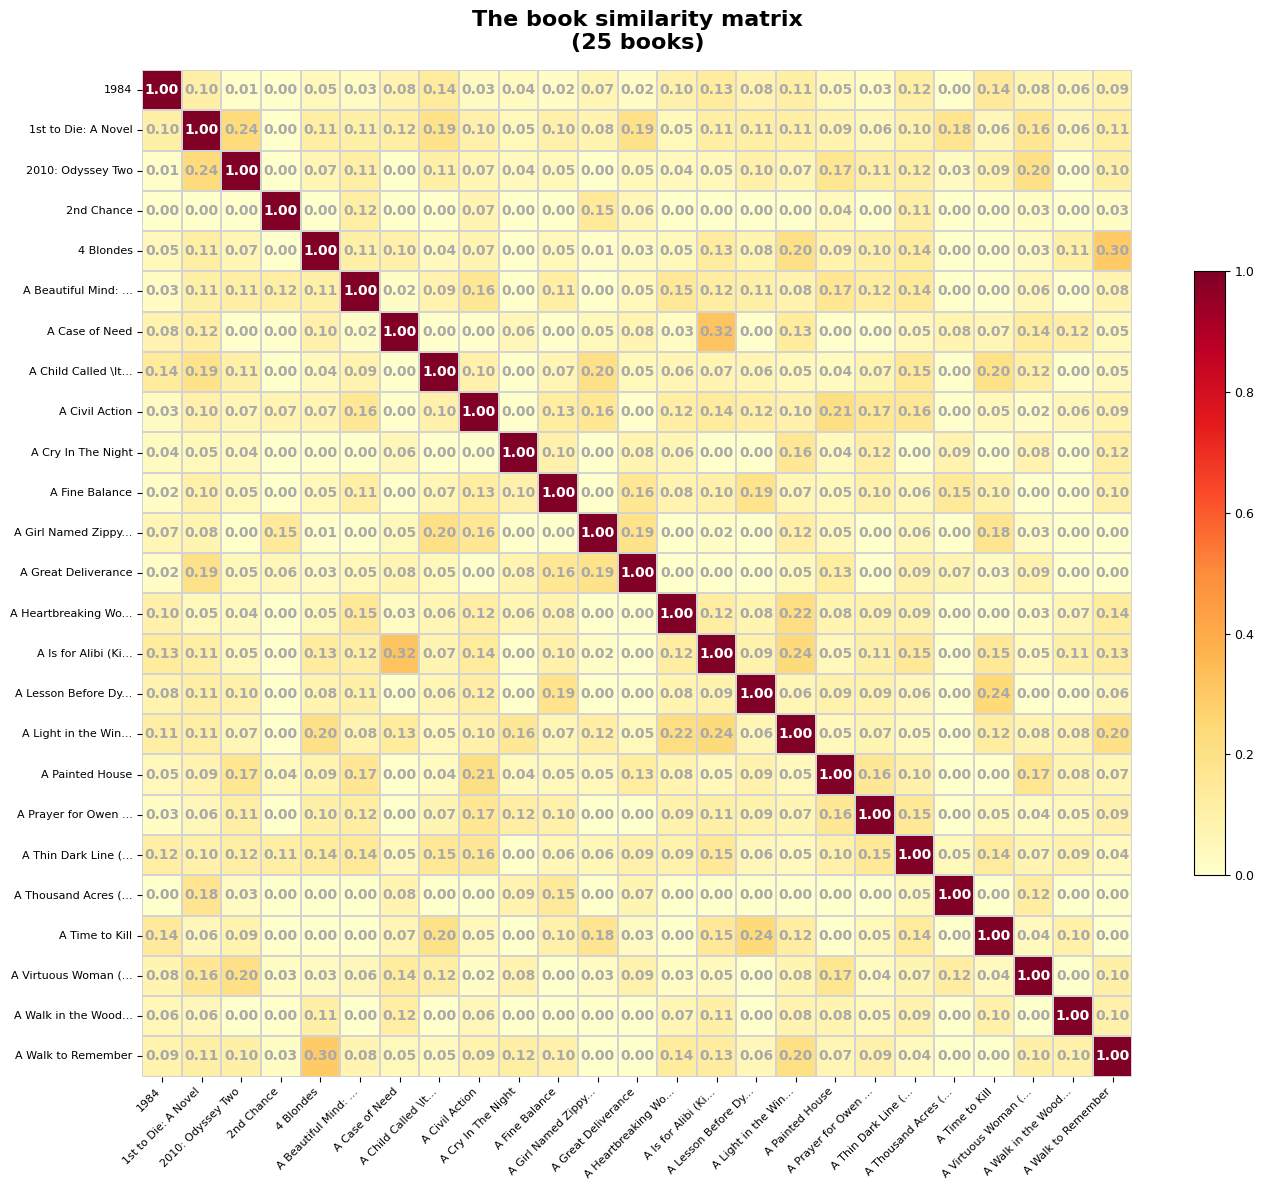

In [ ]:
num_books_to_show = 25
subset_similarity = similarity_score[:num_books_to_show, :num_books_to_show]
book_titles_subset = pivot_table.index[:num_books_to_show].tolist()

# Обрезаем слишком длинные названия
shortened_titles = []
for title in book_titles_subset:
    if len(title) > 20:
        shortened_titles.append(title[:18] + "...")
    else:
        shortened_titles.append(title)

plt.figure(figsize=(14, 12))

# Создаем тепловую карту с желто-красными оттенками (YlOrRd)
ax = sns.heatmap(subset_similarity, 
            xticklabels=shortened_titles,
            yticklabels=shortened_titles,
            cmap='YlOrRd',
            square=False,
            linewidths=0.3,
            linecolor='lightgray',
            annot=True,
            fmt='.2f',
            annot_kws={"size": 10, "weight": "bold"},
            cbar_kws={"shrink": 0.6, "label": "Сходство"},
            vmin=0,
            vmax=1,
            cbar=False)

plt.title(f'The book similarity matrix\n({num_books_to_show} books)', 
          fontsize=16, fontweight='bold', pad=15)

# Настраиваем внешний вид подписей - делаем их меньше для компактности
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

# Настраиваем цвет текста для лучшей читаемости
for text in ax.texts:
    value = float(text.get_text())
    if value > 0.6:
        text.set_color('white')
        text.set_weight('bold')
    elif value > 0.4:
        text.set_color('black')
        text.set_weight('bold')
    else:
        text.set_color('darkgray')

# Добавляем отдельную цветовую шкалу сбоку для экономии места
cbar = plt.colorbar(ax.collections[0], ax=ax, orientation='vertical', shrink=0.6)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

Рекомендательная функция: Функция recommend_books(book_name) находит 5 книг, наиболее похожих на заданную, основываясь на матрице сходства.

In [36]:
def recommend_books(book_name):
    # Check if the book name exists in the index
    if book_name not in final_rating_df.index:
        return f"Book '{book_name}' not found in the recommendation dataset. Please try another book."

    # index fetch
    index = np.where(final_rating_df.index==book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_score[index])),key=lambda x:x[1],reverse=True)[1:6]

    data = []
    for i in similar_items:
        item = []
        temp_df = books[books['Book-Title'] == final_rating_df.index[i[0]]]
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))

        data.append(item)

    print(f"\nRecommendations for the book: '{book_name}'")
    for idx, book_info in enumerate(data, 1):
        print(f"{idx}. {book_info[0]}")
        print(f"   Author: {book_info[1]}")
        print(f"   Image-URL: {book_info[2]}")
        print()

    return data

Testing the Collabrative Filtering

In [37]:
recommend_books("1984")
recommend_books("4 Blondes")
recommend_books("2nd Chance")
recommend_books("The Middle Stories")


Recommendations for the book: '1984'
1. Animal Farm
   Author: George Orwell
   Image-URL: http://images.amazon.com/images/P/0451526341.01.MZZZZZZZ.jpg

2. The Handmaid's Tale
   Author: Margaret Atwood
   Image-URL: http://images.amazon.com/images/P/0449212602.01.MZZZZZZZ.jpg

3. Brave New World
   Author: Aldous Huxley
   Image-URL: http://images.amazon.com/images/P/0060809833.01.MZZZZZZZ.jpg

4. The Vampire Lestat (Vampire Chronicles, Book II)
   Author: ANNE RICE
   Image-URL: http://images.amazon.com/images/P/0345313860.01.MZZZZZZZ.jpg

5. The Hours : A Novel
   Author: Michael Cunningham
   Image-URL: http://images.amazon.com/images/P/0312243022.01.MZZZZZZZ.jpg


Recommendations for the book: '4 Blondes'
1. The House of the Spirits
   Author: Isabel Allende
   Image-URL: http://images.amazon.com/images/P/0553273914.01.MZZZZZZZ.jpg

2. Pride and Prejudice
   Author: Jane Austen
   Image-URL: http://images.amazon.com/images/P/055321215X.01.MZZZZZZZ.jpg

3. Pleading Guilty
   Autho

"Book 'The Middle Stories' not found in the recommendation dataset. Please try another book."

Модель успешно определяет авторское сходство и жанровую принадлежность.